In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, tensorflow as tf
os.makedirs('/content/final_dataset', exist_ok=True)
with zipfile.ZipFile('/content/drive/MyDrive/final_dataset.zip', 'r') as z:
    z.extractall('/content/final_dataset')

Mounted at /content/drive


In [4]:
FINAL_DIR = '/content/final_dataset'
IMG_SIZE, BATCH_SIZE, SEED = (224, 224), 32, 42

val_ds = tf.keras.utils.image_dataset_from_directory(
    FINAL_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)
train_ds = tf.keras.utils.image_dataset_from_directory(
    FINAL_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)
class_names = train_ds.class_names

Found 16767 files belonging to 4 classes.
Using 3353 files for validation.
Found 16767 files belonging to 4 classes.
Using 13414 files for training.


In [5]:
import tensorflow as tf
from tensorflow.keras import layers

class RandomGaussianBlur(layers.Layer):
    """Applies a real 3x3 Gaussian blur to ~prob fraction of batches during training."""
    def __init__(self, prob=0.3, **kwargs):
        super().__init__(**kwargs)
        self.prob = prob

    def call(self, images, training=None):
        if not training:
            return images
        apply_blur = tf.random.uniform([]) < self.prob
        def blur():
            kernel = tf.constant([[1,2,1],[2,4,2],[1,2,1]], dtype=tf.float32) / 16.0
            kernel = tf.reshape(kernel, [3,3,1,1])
            kernel = tf.tile(kernel, [1,1,3,1])
            return tf.nn.depthwise_conv2d(images, kernel, strides=[1,1,1,1], padding='SAME')
        return tf.cond(apply_blur, blur, lambda: images)

    def get_config(self):
        config = super().get_config()
        config.update({"prob": self.prob})
        return config

In [6]:
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/checkpoints/unified_best_model.keras',
    custom_objects={'RandomGaussianBlur': RandomGaussianBlur}
)

                 precision    recall  f1-score   support

 Black_Sigatoka       0.96      0.99      0.98       682
  Fusarium_Wilt       0.99      0.96      0.98       966
        Healthy       0.99      1.00      0.99       698
Not_Banana_Leaf       1.00      1.00      1.00      1007

       accuracy                           0.99      3353
      macro avg       0.99      0.99      0.99      3353
   weighted avg       0.99      0.99      0.99      3353



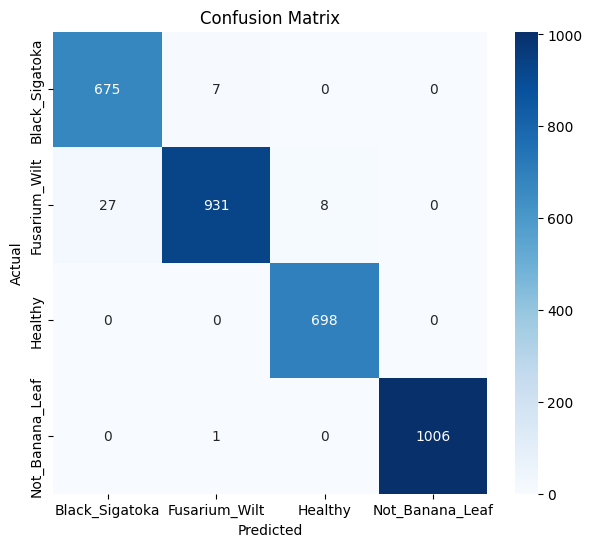

In [7]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns

y_true, y_pred = [], []
for imgs, labels in val_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)
with open('/content/drive/MyDrive/checkpoints/classification_report.txt', 'w') as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/checkpoints/confusion_matrix.png')
plt.show()

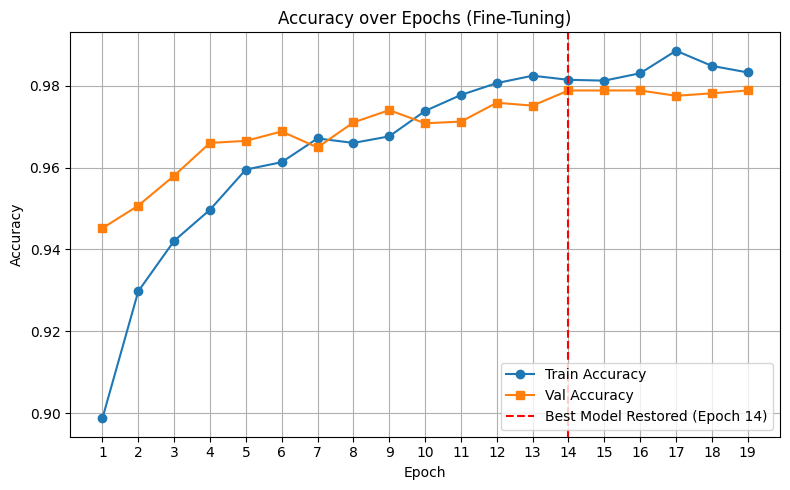

In [8]:
import matplotlib.pyplot as plt

# Fine-tuning accuracy data
epochs = list(range(1, 20))
train_acc = [
    0.8988, 0.9298, 0.9421, 0.9497, 0.9595, 0.9613, 0.9671, 0.9660, 0.9676,
    0.9738, 0.9777, 0.9806, 0.9824, 0.9814, 0.9812, 0.9830, 0.9885, 0.9848, 0.9832
]  # Or replace with: history.history['accuracy'][:19]
val_acc = [
    0.9452, 0.9507, 0.9580, 0.9660, 0.9665, 0.9688, 0.9649, 0.9710, 0.9740,
    0.9708, 0.9712, 0.9758, 0.9751, 0.9788, 0.9788, 0.9788, 0.9775, 0.9781, 0.9788
]  # Or replace with: history.history['val_accuracy'][:19]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='s', label='Val Accuracy')
plt.axvline(x=14, color='red', linestyle='--', label='Best Model Restored (Epoch 14)')

plt.title('Accuracy over Epochs (Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.grid(True)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

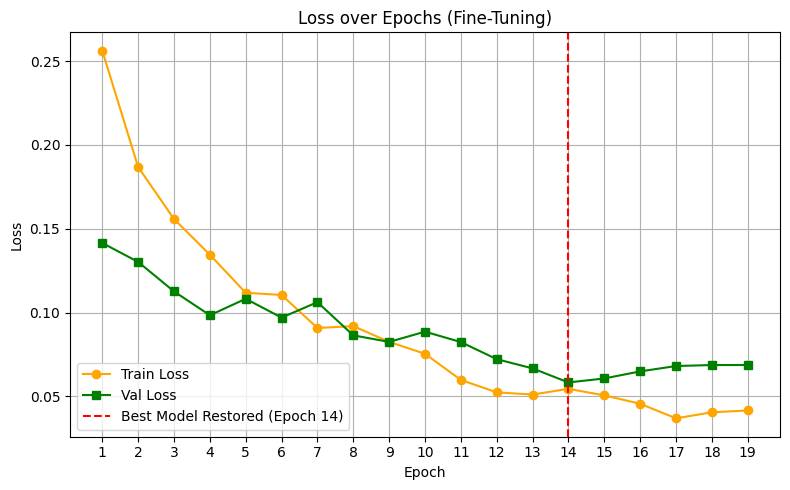

In [9]:
import matplotlib.pyplot as plt

# Fine-tuning loss data
epochs = list(range(1, 20))
train_loss = [
    0.2562, 0.1868, 0.1558, 0.1345, 0.1118, 0.1105, 0.0908, 0.0919, 0.0825,
    0.0754, 0.0598, 0.0524, 0.0511, 0.0545, 0.0506, 0.0456, 0.0369, 0.0405, 0.0416
]  # Or replace with: history.history['loss'][:19]
val_loss = [
    0.1415, 0.1302, 0.1126, 0.0984, 0.1082, 0.0970, 0.1062, 0.0864, 0.0825,
    0.0886, 0.0824, 0.0722, 0.0667, 0.0583, 0.0607, 0.0649, 0.0681, 0.0687, 0.0687
]  # Or replace with: history.history['val_loss'][:19]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', color='orange', label='Train Loss')
plt.plot(epochs, val_loss, marker='s', color='green', label='Val Loss')
plt.axvline(x=14, color='red', linestyle='--', label='Best Model Restored (Epoch 14)')

plt.title('Loss over Epochs (Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.grid(True)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()